# 2023 날씨데이터 머신러닝

In [1]:
import pandas as pd
weather=pd.read_excel("weather2023.xlsx",index_col='date')
weather.head()

,location,loc_name,temp,rain,wind,humi,sunshine,cloud
date,,,,,,,,
2023-01-01,108,서울,-0.2,NaN,2.7,55.0,9.0,1.3
2023-01-02,108,서울,-4.5,NaN,2.5,46.0,9.1,0.0
2023-01-03,108,서울,-5.0,NaN,1.8,49.0,9.1,0.0
2023-01-04,108,서울,-1.8,NaN,1.9,51.0,8.7,1.9
2023-01-05,108,서울,-1.6,NaN,1.6,58.1,4.7,3.6


In [2]:
weather.isnull().sum()
weather.drop(['location','loc_name','rain'], axis=1, inplace=True)
weather.isnull().sum()


temp        0
wind        0
humi        0
sunshine    0
cloud       0
dtype: int64

In [3]:
weather.head()

,temp,wind,humi,sunshine,cloud
date,,,,,
2023-01-01,-0.2,2.7,55.0,9.0,1.3
2023-01-02,-4.5,2.5,46.0,9.1,0.0
2023-01-03,-5.0,1.8,49.0,9.1,0.0
2023-01-04,-1.8,1.9,51.0,8.7,1.9
2023-01-05,-1.6,1.6,58.1,4.7,3.6


# 2 데이터 분석 및 시각화하기

## 통계 출력


In [ ]:
weather.describe() # describe(): 데이터 프레임이나 특정열의 기초 통계값을 한번에 확인하는 메서드 각 열의 개수, 평균,표준편차, 최소값, 사분위수, 최대값을 보여줌

,temp,wind,humi,sunshine,cloud
count,181.000000,181.000000,181.000000,181.000000,181.000000
mean,11.276796,2.346961,61.373481,6.861326,4.477348
std,9.443758,0.559220,15.324725,3.946637,3.006232
min,-14.700000,1.500000,22.900000,0.000000,0.000000
25%,3.100000,2.000000,50.400000,3.700000,1.900000
50%,12.500000,2.300000,60.800000,7.800000,4.400000
75%,19.500000,2.600000,70.000000,10.000000,6.600000
max,28.500000,5.400000,99.100000,13.300000,10.000000


In [5]:
weather.corr()

,temp,wind,humi,sunshine,cloud
temp,1.000000,-0.159365,0.188156,0.006086,0.322875
wind,-0.159365,1.000000,0.028151,-0.045892,0.015210
humi,0.188156,0.028151,1.000000,-0.623116,0.557944
sunshine,0.006086,-0.045892,-0.623116,1.000000,-0.825506
cloud,0.322875,0.015210,0.557944,-0.825506,1.000000


### 일조량과 전운량은 강한 음의 상관관계를 가진다. 구름의 양이 많을수록 일조량은 대체로 감소한다.

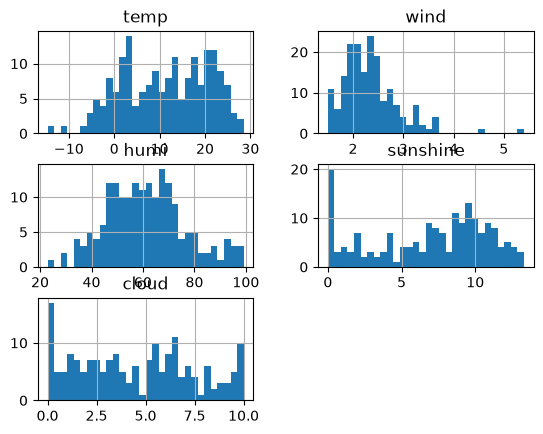

In [6]:
import matplotlib.pyplot as plt
weather.hist(bins=30)
plt.show()

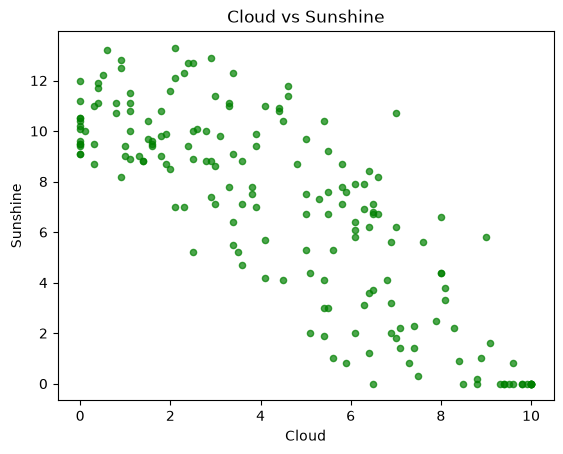

In [14]:
import matplotlib.pyplot as plt
weather.plot(x='cloud', y='sunshine', kind='scatter', color='green', alpha=0.7)
plt.xlabel('Cloud')
plt.ylabel('Sunshine')
plt.title('Cloud vs Sunshine')
plt.show()

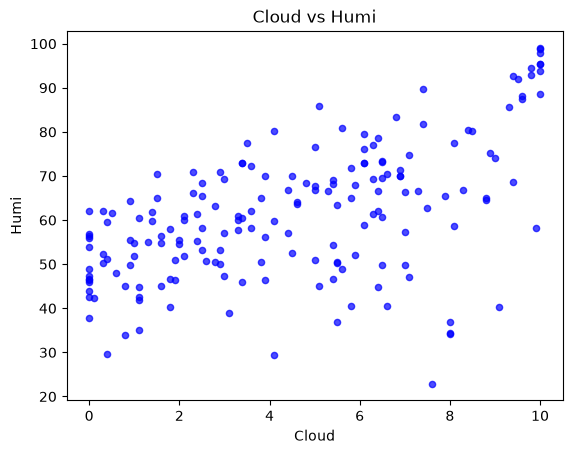

In [16]:
weather.plot(x='cloud', y='humi', kind='scatter', color='blue', alpha=0.7)
plt.xlabel('Cloud')
plt.ylabel('Humi')
plt.title('Cloud vs Humi')
plt.show()

(3) 결과 해석 및 통찰
1. 전운량과 일조량의 상관계수가 약 -0.03으로 강한 음의 상관관계를 가짐
2. 따라서 전운량이 증가하면 일조량은 감소하는 경향이 있음을 알 수 있음
3. 전운량과 습도의 상관계수는 약 0.56으로, 전운량이 증가할수록 습도가 높아지는 경향이 나타남